# Demand forecast experiment

This notebook evaluates a weekly retail demand forecasting workflow for Program-25.

In [1]:
import pandas as pd

weekly_sales = pd.read_csv('weekly_sales.csv')
weekly_sales.head()

,week,units
0,1,100
1,2,103
2,3,106
3,4,109
4,5,112


## Forecast model

The helper function `forecast_demand` trains a simple moving-average baseline.

In [2]:
def forecast_demand(frame, window=4):
    forecast = frame['units'].rolling(window).mean()
    return forecast

forecast = forecast_demand(weekly_sales)
residuals = weekly_sales['units'] - forecast
pd.Series({'mae': residuals.abs().mean(), 'mape': (residuals.abs() / weekly_sales['units']).mean()})

mae     6.500000
mape    0.055542
dtype: float64

## Plot

The final chart compares actual weekly units against the moving-average forecast.

<Axes: xlabel='week'>

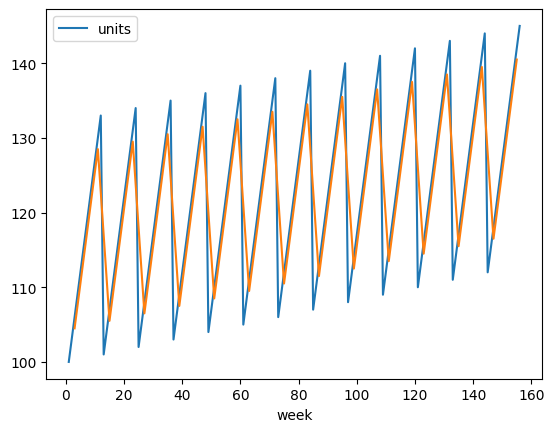

In [3]:
ax = weekly_sales.plot(x='week', y='units')
forecast.plot(ax=ax)